In [12]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector
from PIL import Image

%matplotlib widget

In [3]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB18_3n1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [4]:
channel = 1
time = 100
img, img_disp = get_frame(czi,time,channel)

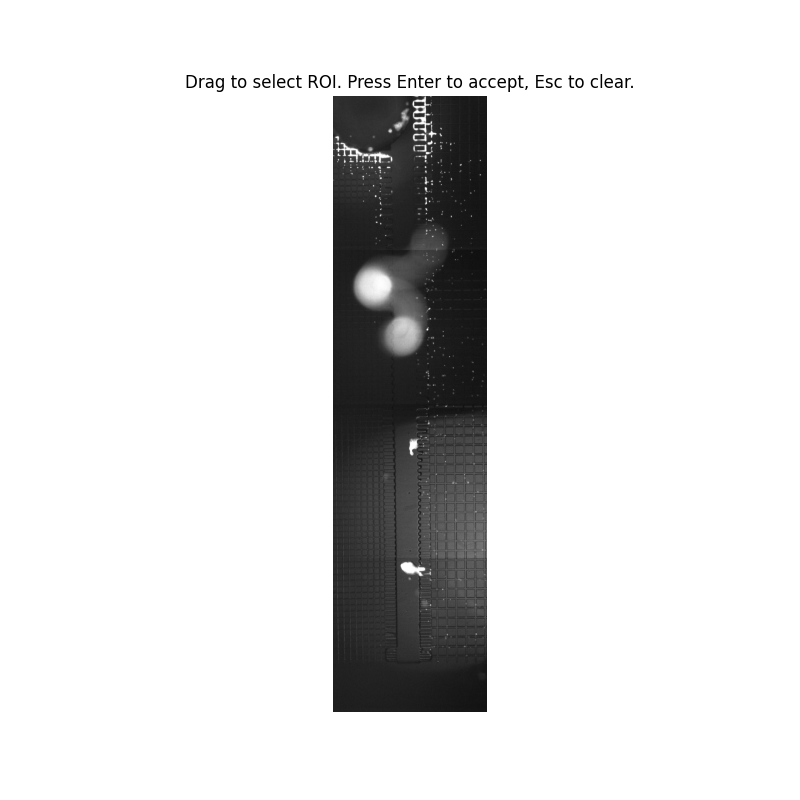

In [5]:
roi = ROI_selector(img)

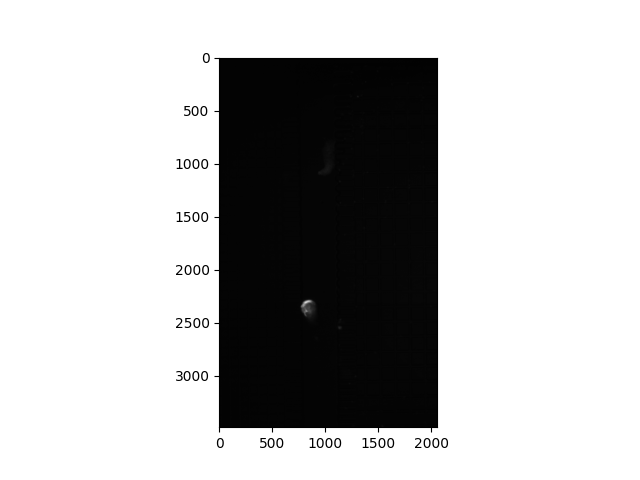

In [7]:
channel = 1
time = 110
img, img_disp = get_frame(czi,time,channel,roi=roi,gamma=1)
fig,ax = plt.subplots()
ax.imshow(img,cmap="gray")

In [9]:
times

[(0,
  datetime.datetime(2026, 1, 12, 12, 45, 19, 993613, tzinfo=datetime.timezone.utc)),
 (1,
  datetime.datetime(2026, 1, 12, 12, 55, 18, 532947, tzinfo=datetime.timezone.utc)),
 (2,
  datetime.datetime(2026, 1, 12, 13, 5, 18, 518471, tzinfo=datetime.timezone.utc)),
 (3,
  datetime.datetime(2026, 1, 12, 13, 15, 18, 551826, tzinfo=datetime.timezone.utc)),
 (4,
  datetime.datetime(2026, 1, 12, 13, 25, 18, 516089, tzinfo=datetime.timezone.utc)),
 (5,
  datetime.datetime(2026, 1, 12, 13, 35, 18, 556246, tzinfo=datetime.timezone.utc)),
 (6,
  datetime.datetime(2026, 1, 12, 13, 45, 18, 552209, tzinfo=datetime.timezone.utc)),
 (7,
  datetime.datetime(2026, 1, 12, 13, 55, 18, 554697, tzinfo=datetime.timezone.utc)),
 (8,
  datetime.datetime(2026, 1, 12, 14, 5, 18, 565651, tzinfo=datetime.timezone.utc)),
 (9,
  datetime.datetime(2026, 1, 12, 14, 15, 18, 567465, tzinfo=datetime.timezone.utc)),
 (10,
  datetime.datetime(2026, 1, 12, 14, 25, 18, 517647, tzinfo=datetime.timezone.utc)),
 (11,
  dat

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_15763/1358120255.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode=mode)


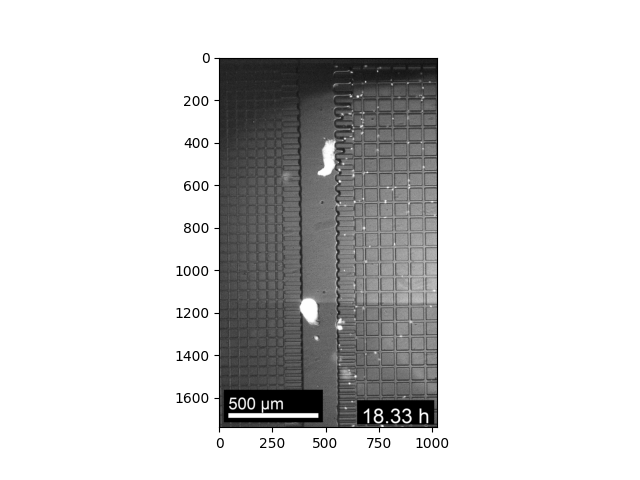

In [10]:
frame = make_annotated(
    img_disp,
    time,
    times,
    pixel_size["X"],
    resize_width= 1024,
    mode = "L"
)
fig,ax = plt.subplots()
ax.imshow(frame,cmap="gray")

In [13]:
_, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi)

ch_magenta = norm(ch_magenta)

rgb_magenta = mcherry(ch_magenta)[..., :3]


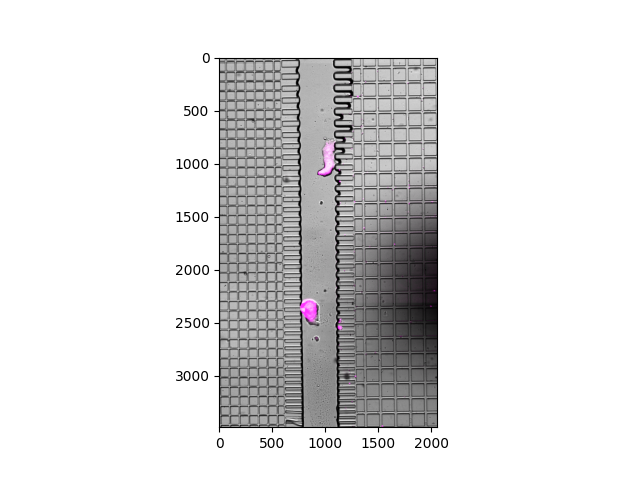

In [26]:
stretch_min = 96
stretch_max = 99.5
_, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi,    stretch_min = stretch_min, stretch_max = stretch_max)
_, ch_gray    = get_frame(czi, time, 2, gamma=1, roi=roi)

ch_magenta = norm(ch_magenta)
ch_gray    = norm(ch_gray)

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

In [27]:
# ---- your settings ----
scale_factor = 6000.0   # 10x faster
fps = 10
output = "/Users/bisot/Documents/PostDoc2/test_data/movie.mp4"

# Parse timestamps
frame_idxs = [i for i, _ in times]
ts = [s for _, s in times]

# Compute real deltas (seconds)
real_deltas = [None]
for k in range(1, len(ts)):
    dt = max((ts[k] - ts[k-1]).total_seconds(), 0.0)
    real_deltas.append(dt)

positive = [d for d in real_deltas[1:] if d and d > 0]
baseline = median(positive) if positive else 1.0
real_deltas[0] = baseline
if len(real_deltas) > 1:
    real_deltas[-1] = real_deltas[-2] if real_deltas[-2] is not None else baseline

video_durations = [clamp(float(d) / scale_factor, 0.0, 1e12) for d in real_deltas]

# Build clips
clips = []
for (frame_i, (time_i, _)), dur in zip(enumerate(times), video_durations):
    # NOTE: you currently loop "for time,_ in times:" where time is frame index.
    time = time_i

    _, ch_magenta = get_frame(czi, time, 1,gamma=1, roi=roi, stretch_min = stretch_min, stretch_max = stretch_max)
    _, ch_gray    = get_frame(czi, time, 2, gamma=1, roi=roi)

    ch_magenta = norm(ch_magenta)
    ch_gray    = norm(ch_gray)

    rgb_magenta = mcherry(ch_magenta)[..., :3]
    rgb_gray    = gray_cmap(ch_gray)[..., :3]
    merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)

    frame = make_annotated(
        merged,
        time,
        times,          # pass indices (or your original list, up to you)
        pixel_size["X"],
        resize_width=1024,
        mode="RGB",
    )

    # Ensure uint8 for MoviePy
    if frame.dtype != np.uint8:
        frame_u8 = (np.clip(frame, 0, 1) * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8)
    else:
        frame_u8 = frame

    clips.append(ImageClip(frame_u8, duration=dur))

final = concatenate_videoclips(clips, method="compose")
final.write_videofile(
    output,
    fps=fps,
    codec="libx264",
    audio=False,
    ffmpeg_params=[
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-profile:v", "baseline",
        "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
    ],
)

print("✅ Done:", output)


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_15763/1358120255.py:30: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(np_img_u8, mode=mode)


MoviePy - Building video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4.
MoviePy - Writing video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4



MoviePy - Done !
MoviePy - video ready /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
✅ Done: /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
